##  ACTIVIDAD 1  

Jorge Oviedo Magaña

 # Regresiones lineales de orden 1,3,5 y 7 (bateria_tableta)

In [4]:
import pandas as pd

Salarios_minimos = pd.read_csv('Salarios_minimos.csv')
bateria_tableta = pd.read_csv('bateria_tableta.txt')

In [5]:
#quiero sacar la info de los dataframes
Salarios_minimos.head()


,Periodo,Salario
0,1988.25,8.00
1,1989.00,8.64
2,1989.50,9.16
3,1990.00,10.08
4,1990.84,11.90


In [6]:
bateria_tableta.head()

,carga,duracion
0,2.81,5.62
1,7.14,8.00
2,2.72,5.44
3,3.87,7.74
4,1.90,3.80


In [7]:
#Con un exponente (y^ = b^{0 + b1*x)

from sklearn.linear_model import LinearRegression
lr = LinearRegression() # it creates the model
x = bateria_tableta[["carga"]]
y = bateria_tableta[["duracion"]]

lr.fit(x,y) # it fits the model
lr.coef_ # it gives the coefficients of the variables in order
lr.intercept_ # it gives the intercept

array([2.87054111])

In [8]:
#con dos exponentes (y = b0 + b1*x + b2*x^2)
from sklearn.preprocessing import PolynomialFeatures
lr= LinearRegression()
#si carga es x, necesito carga al cuadrado

x_poly3 = [(x, x**2, x**3) for x in bateria_tableta["carga"]]
y = bateria_tableta[["duracion"]]
lr.fit(x_poly3,y)
lr.coef_

array([[ 3.34240792, -0.39326189,  0.01452403]])

In [9]:
# con 5 exponentes (y = b0 + b1*x + b2*x^2 + b3*x^3 + b4*x^4 + b5*x^5)

#si carga es x, necesito carga al cubo y al cuadrado
x_poly5 = [(x, x**2, x**3, x**4, x**5) for x in bateria_tableta["carga"]]
lr.fit(x_poly5,y)
lr.coef_


array([[ 8.35890085e-01,  1.10347381e+00, -3.23550360e-01,
         3.20123836e-02, -1.07054199e-03]])

In [10]:
# con 7 exponentes (y = b0 + b1*x + b2*x^2 + b3*x^3 + b4*x^4 + b5*x^5 + b6*x^6 + b7*x^7)

x_poly7 = [(x, x**2, x**3, x**4, x**5, x**6, x**7) for x in bateria_tableta["carga"]]
lr.fit(x_poly7,y)
lr.coef_


array([[ 2.63586646e+00, -1.38252388e+00,  1.01240187e+00,
        -3.16715233e-01,  4.60134802e-02, -3.15491538e-03,
         8.27801489e-05]])

# Ahora con el archivo de Salarios_minimos


In [11]:
x1 = Salarios_minimos[["Periodo"]]
y1 = Salarios_minimos[["Salario"]]

lr.fit(x,y)
lr.coef_


array([[0.72955585]])

In [12]:
x_pol3 = [(x, x**2, x**3) for x in Salarios_minimos["Periodo"]]
lr.fit(x_pol3,y1)
lr.coef_

array([[ 7.83146244e+03, -3.91934110e+00,  6.54024500e-04]])

In [13]:
x_pol5 = [(x, x**2, x**3, x**4, x**5) for x in Salarios_minimos["Periodo"]]
lr.fit(x_pol5,y1)
lr.coef_

array([[ 3.32926286e-10,  6.66841148e-07,  6.67827159e-04,
        -5.01138166e-07,  1.00311032e-10]])

In [14]:
x_poly7 = [(x, x**2, x**3, x**4, x**5, x**6, x**7) for x in bateria_tableta["carga"]]
lr.fit(x_poly7,y)
lr.coef_

array([[ 2.63586646e+00, -1.38252388e+00,  1.01240187e+00,
        -3.16715233e-01,  4.60134802e-02, -3.15491538e-03,
         8.27801489e-05]])

# Comparacion modelos


--- Resultados: Salarios Mínimos ---
Grado 1: R2 = 0.98446
Grado 3: R2 = 0.98574
Grado 5: R2 = 0.98575
Grado 7: R2 = 0.98577


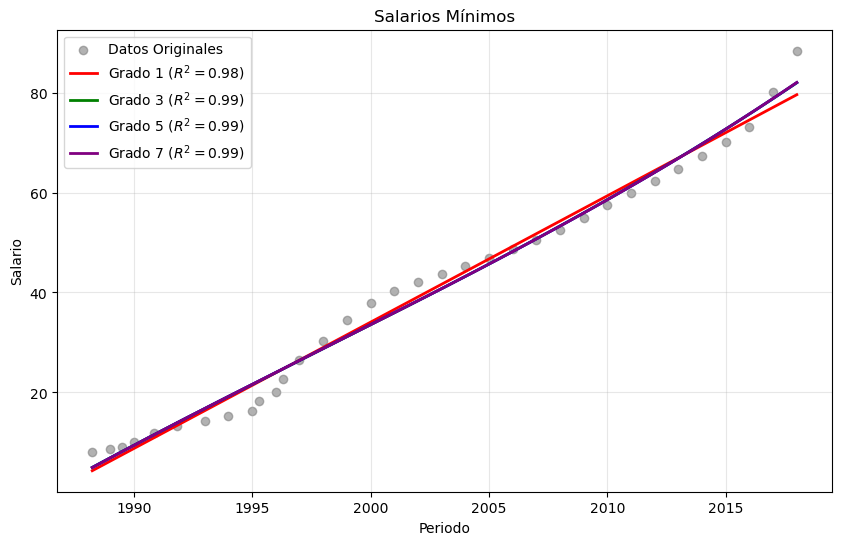


--- Resultados: Batería Tableta ---
Grado 1: R2 = 0.68723
Grado 3: R2 = 0.97807
Grado 5: R2 = 0.99536
Grado 7: R2 = 0.99810


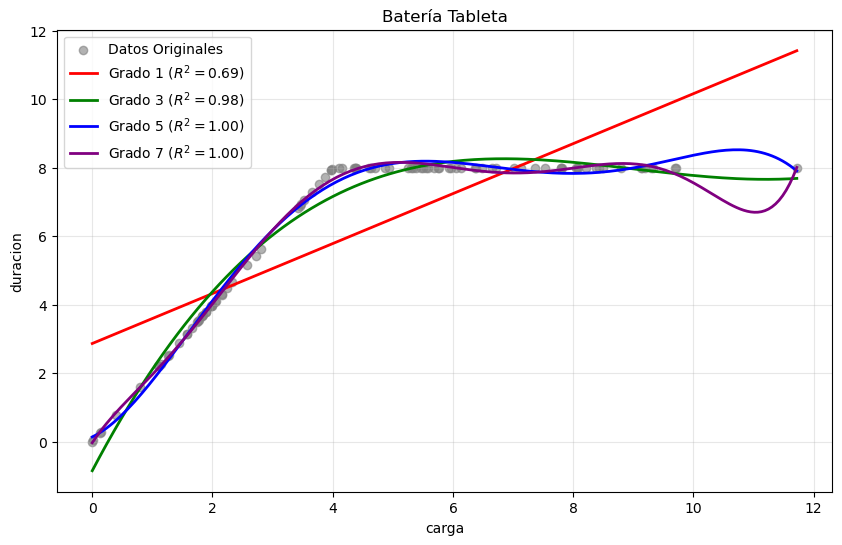

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# 1. Definimos la función (solo una vez)
def analizar_y_mostrar(df, col_x, col_y, titulo):
    # Extraemos datos
    X = df[[col_x]].values
    y = df[col_y].values
    
    # Ordenamos para que el gráfico se vea bien (líneas continuas)
    idx = np.argsort(X[:, 0])
    X_ord = X[idx]
    y_ord = y[idx]
    
    # Configuración del gráfico
    plt.figure(figsize=(10, 6))
    plt.scatter(X_ord, y_ord, color='gray', label='Datos Originales', alpha=0.6)
    
    grados = [1, 3, 5, 7]
    colores = ['red', 'green', 'blue', 'purple']
    
    print(f"\n--- Resultados: {titulo} ---")
    
    # Rango suave para dibujar las curvas
    X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    
    for i, grado in enumerate(grados):
        # A. Transformación
        poly = PolynomialFeatures(degree=grado)
        X_poly = poly.fit_transform(X_ord)
        X_plot_poly = poly.transform(X_plot)
        
        # B. Ajuste
        modelo = LinearRegression()
        modelo.fit(X_poly, y_ord)
        
        # C. R2
        y_pred = modelo.predict(X_poly)
        r2 = r2_score(y_ord, y_pred)
        
        print(f"Grado {grado}: R2 = {r2:.5f}")
        
        # D. Graficar
        y_plot_pred = modelo.predict(X_plot_poly)
        plt.plot(X_plot, y_plot_pred, color=colores[i], linewidth=2, 
                 label=f'Grado {grado} ($R^2={r2:.2f}$)')
    
    plt.title(titulo)
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # Importante para ver la gráfica

# 2. EJECUCIÓN (Aquí es donde se generan los resultados)

# Para Salarios Mínimos
if 'Salarios_minimos' in locals():
    analizar_y_mostrar(Salarios_minimos, 'Periodo', 'Salario', 'Salarios Mínimos')
else:
    print("⚠️ Error: La variable 'Salarios_minimos' no está cargada.")

# Para Batería Tableta
if 'bateria_tableta' in locals():
    analizar_y_mostrar(bateria_tableta, 'carga', 'duracion', 'Batería Tableta')
else:
    print("⚠️ Error: La variable 'bateria_tableta' no está cargada.")
